
Running simulation for model: SARIMA
Loading data files...
Loaded 137 predictions
Date range: 2025-05-15 00:00:00 to 2025-12-24 00:00:00

Predictions breakdown:
predicted
1    91
0    46
Name: count, dtype: int64
  Predicted UP (1): 91 (66.4%)
  Predicted DOWN (0): 46 (33.6%)

Loaded 6425 stock data rows
Date range: 1997-07-20 00:00:00 to 2025-12-24 00:00:00

Stock data columns: ['s', 'o', 'h', 'l', 'c', 'v', 'date', 'psar', 'PosDI', 'NegDI', 'ADX', 'accumulated_sentiment']

RUNNING PORTFOLIO SIMULATION

Using columns: Open='o', Close='c'
Trade #  1 | Entry: 2025-05-18 @ $2608.26 | Exit: 2025-05-22 @ $2688.55 | P&L: $+281.36 (+2.82%) | Commission: $50.64
Trade #  2 | Entry: 2025-05-26 @ $2712.69 | Exit: 2025-06-03 @ $2658.93 | P&L: $-227.82 (-2.23%) | Commission: $50.65
Trade #  3 | Entry: 2025-06-04 @ $2660.22 | Exit: 2025-06-10 @ $2678.17 | P&L: $+42.21 (+0.42%) | Commission: $50.06
Trade #  4 | Entry: 2025-06-11 @ $2677.53 | Exit: 2025-06-17 @ $2654.75 | P&L: $-109.81 (-1.10%) | Co

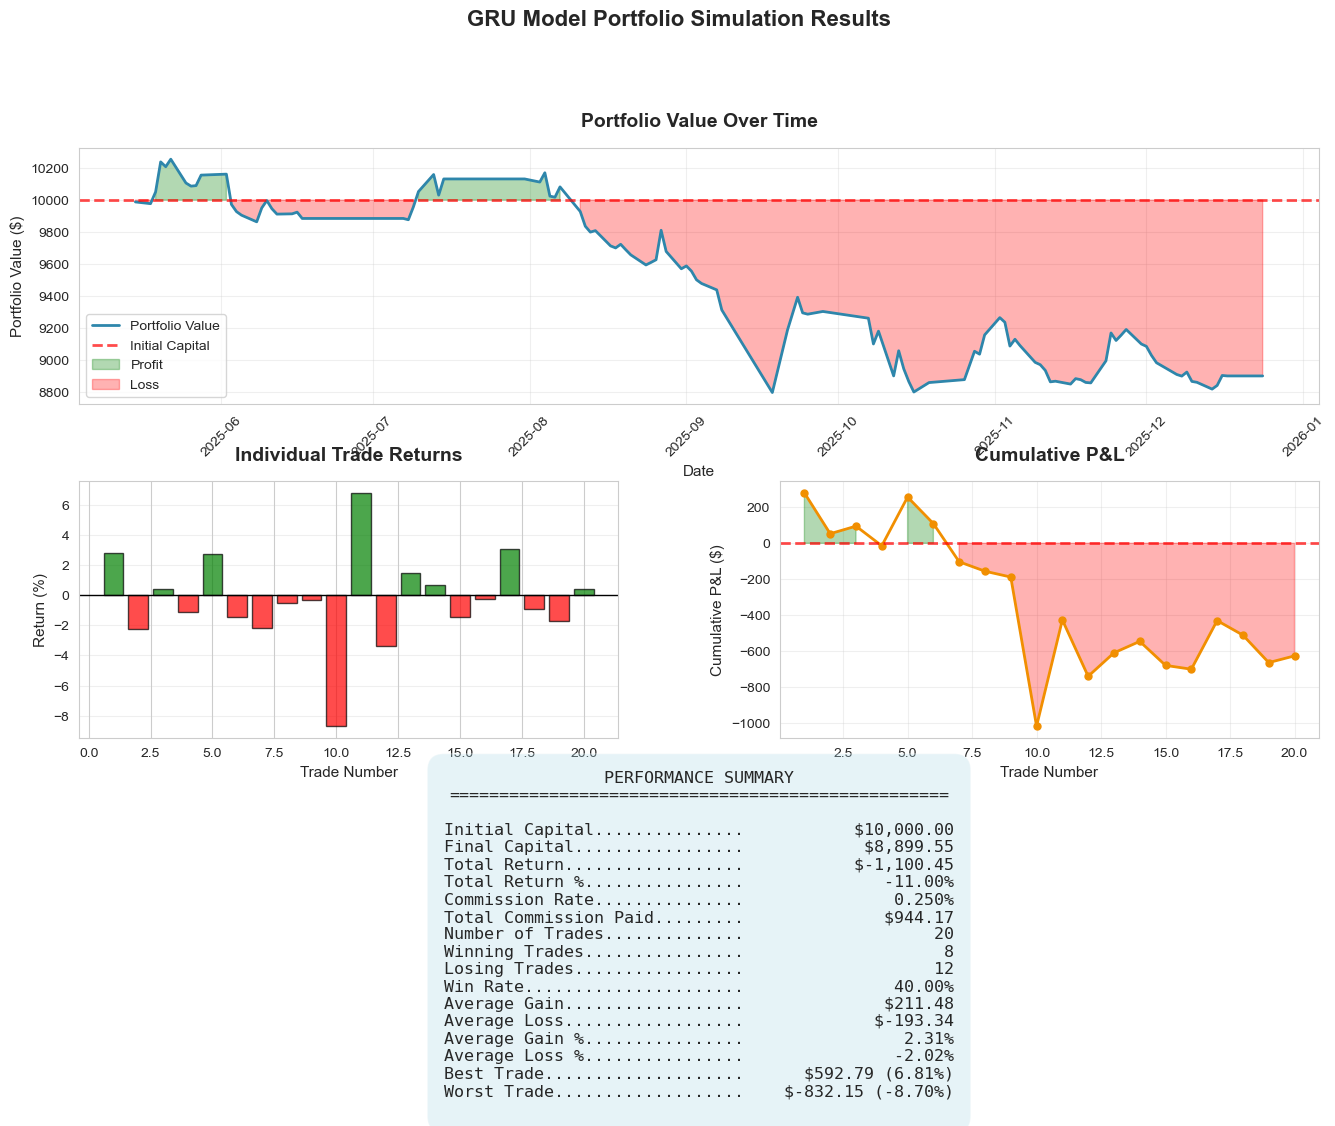

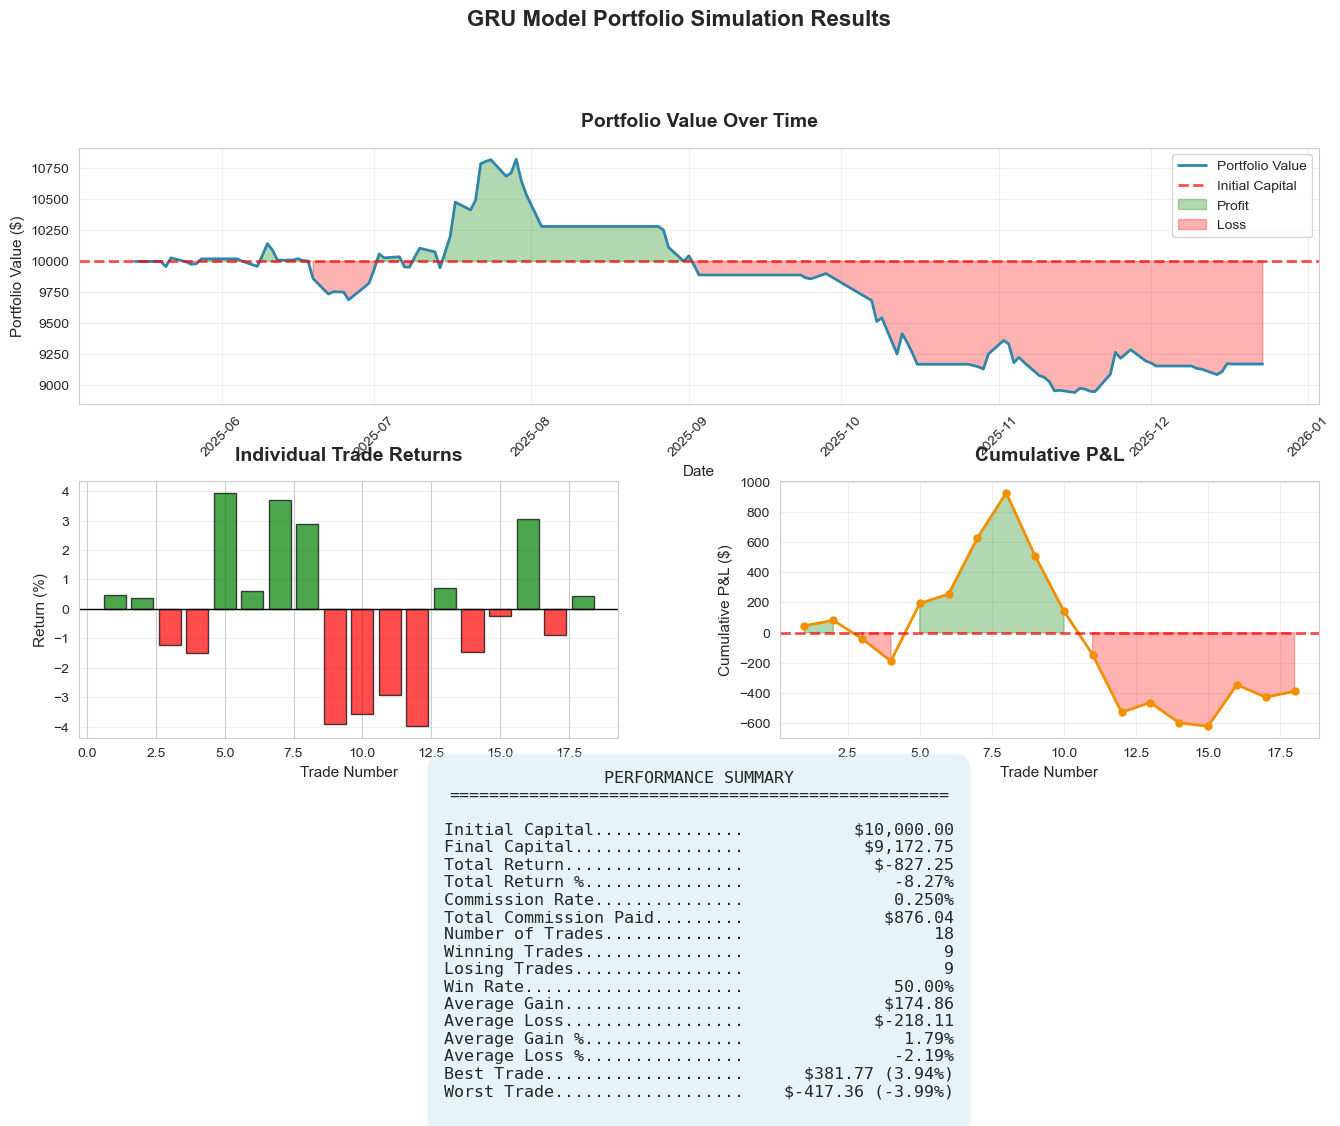

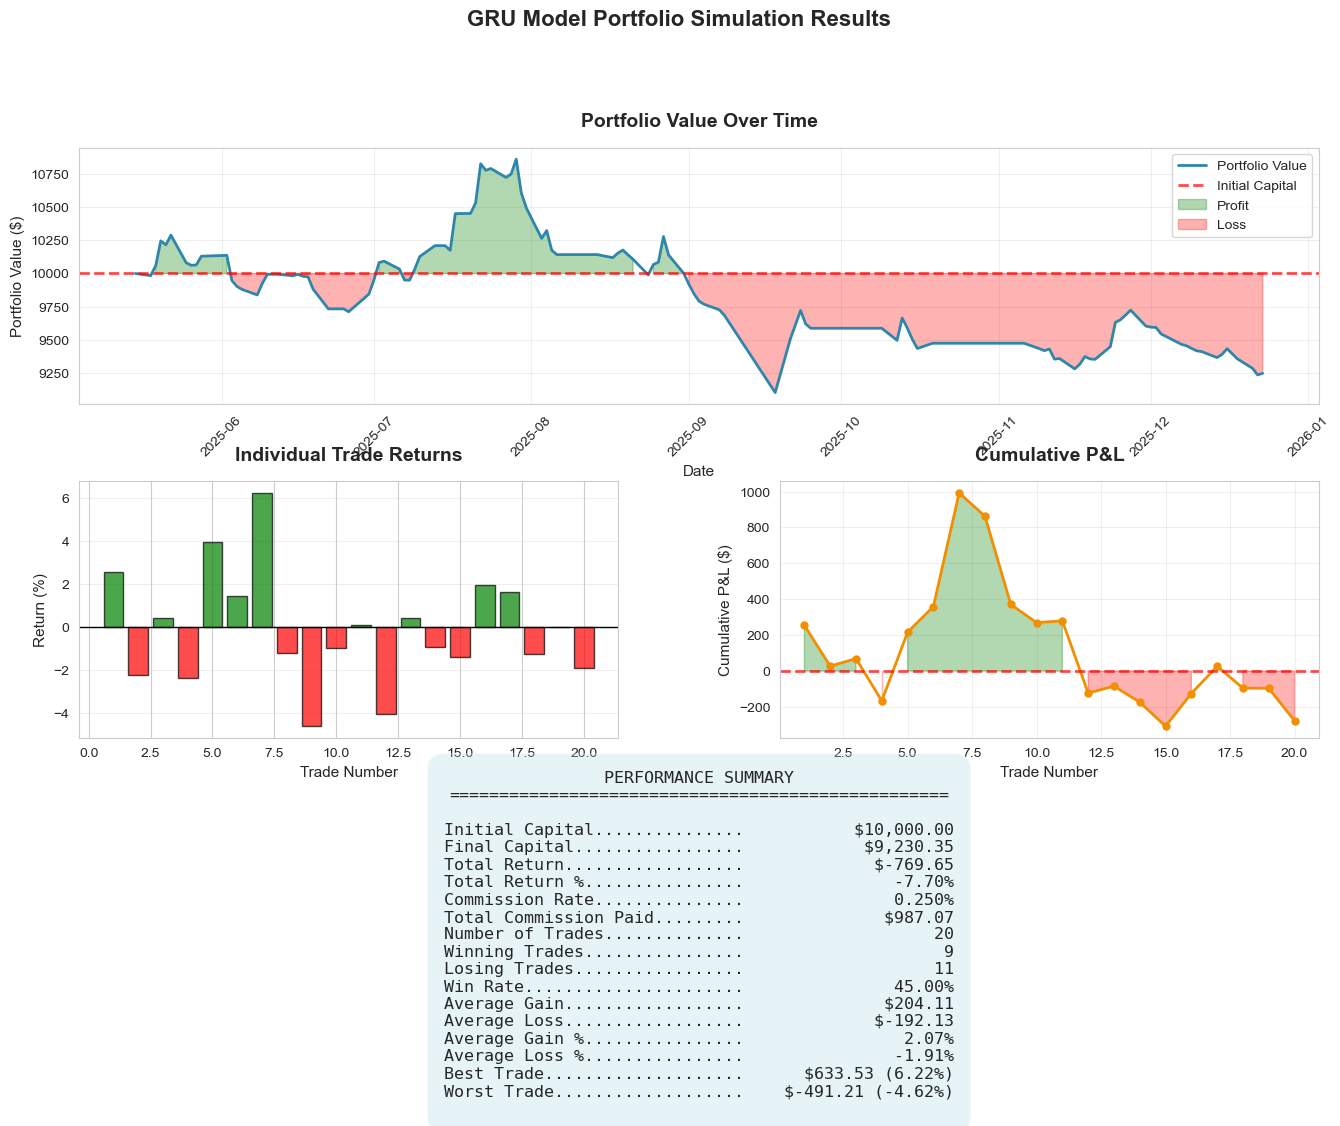

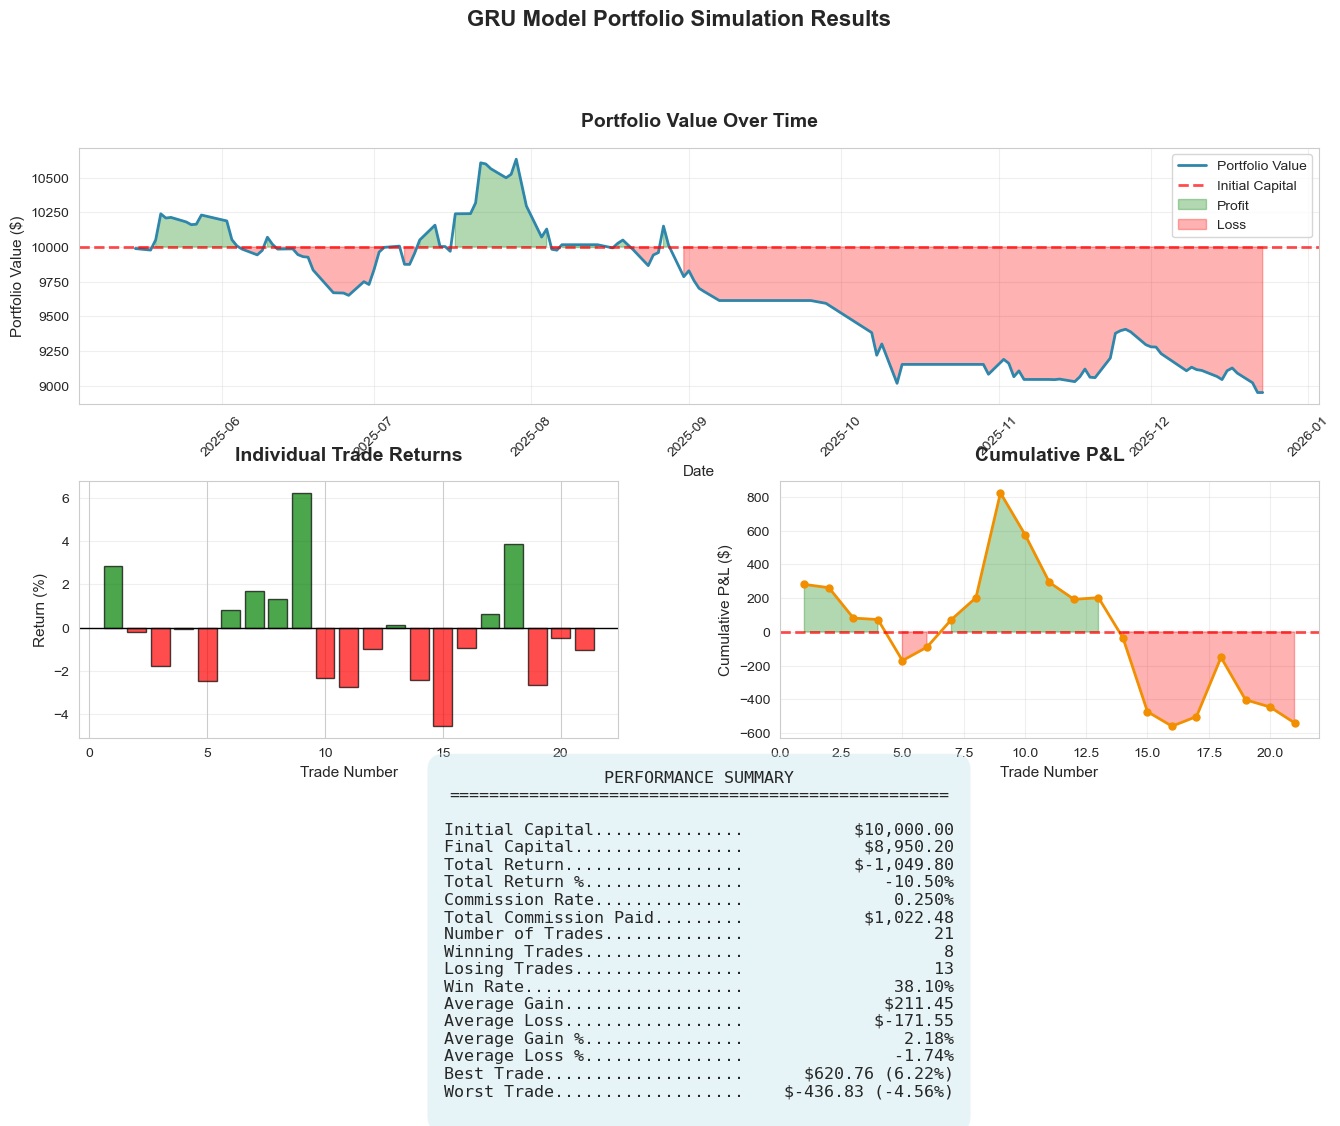

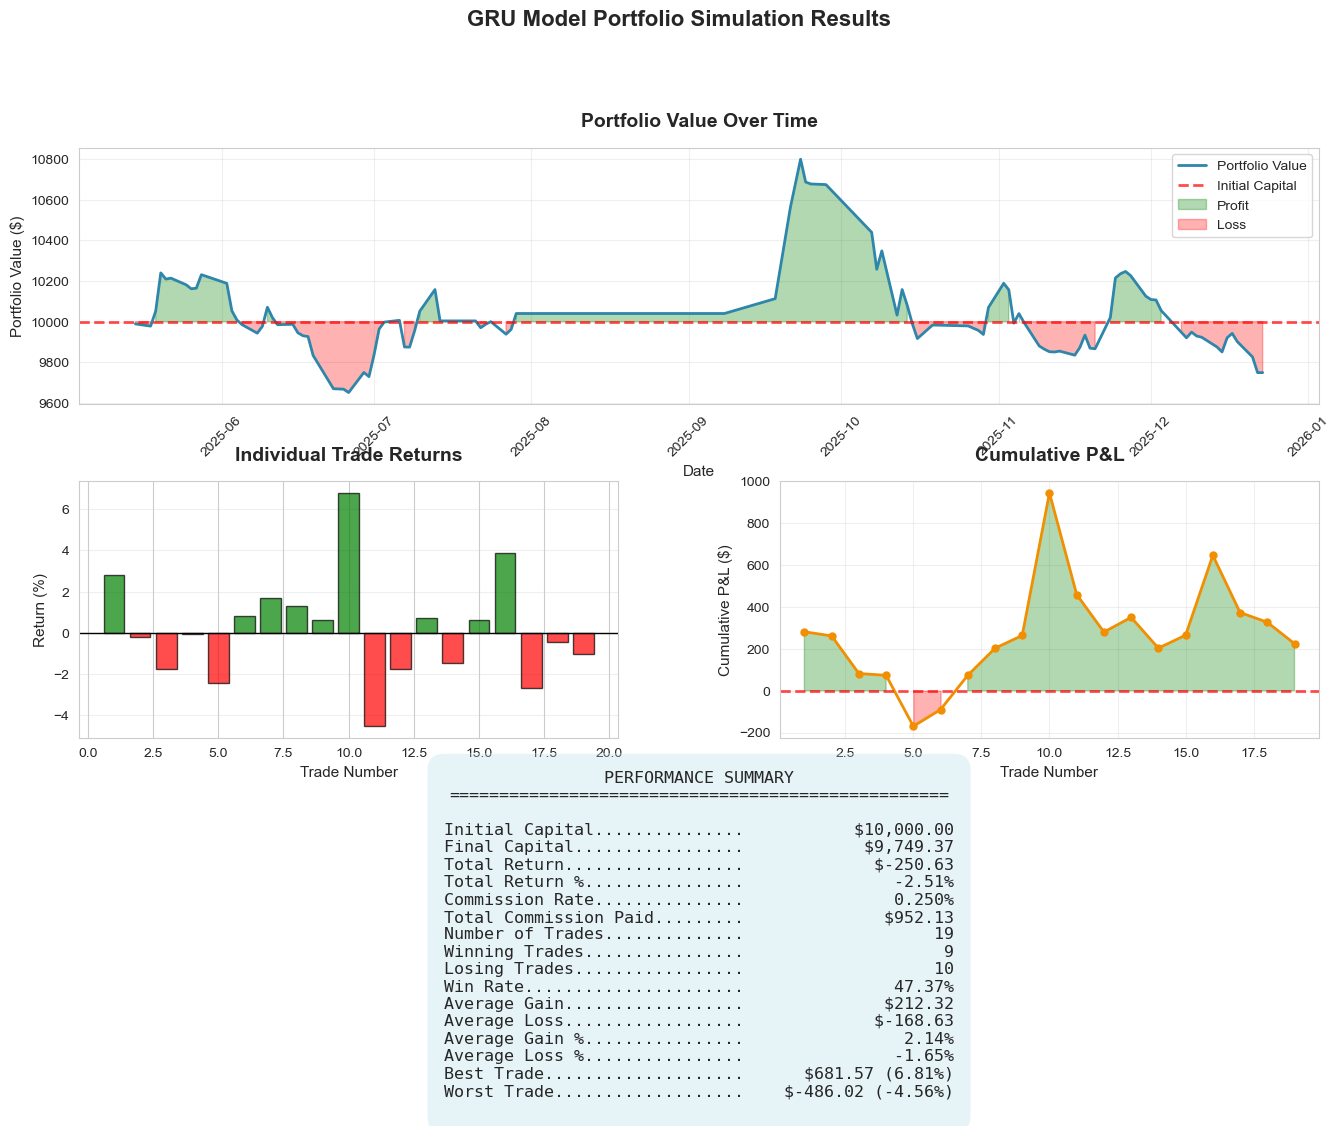

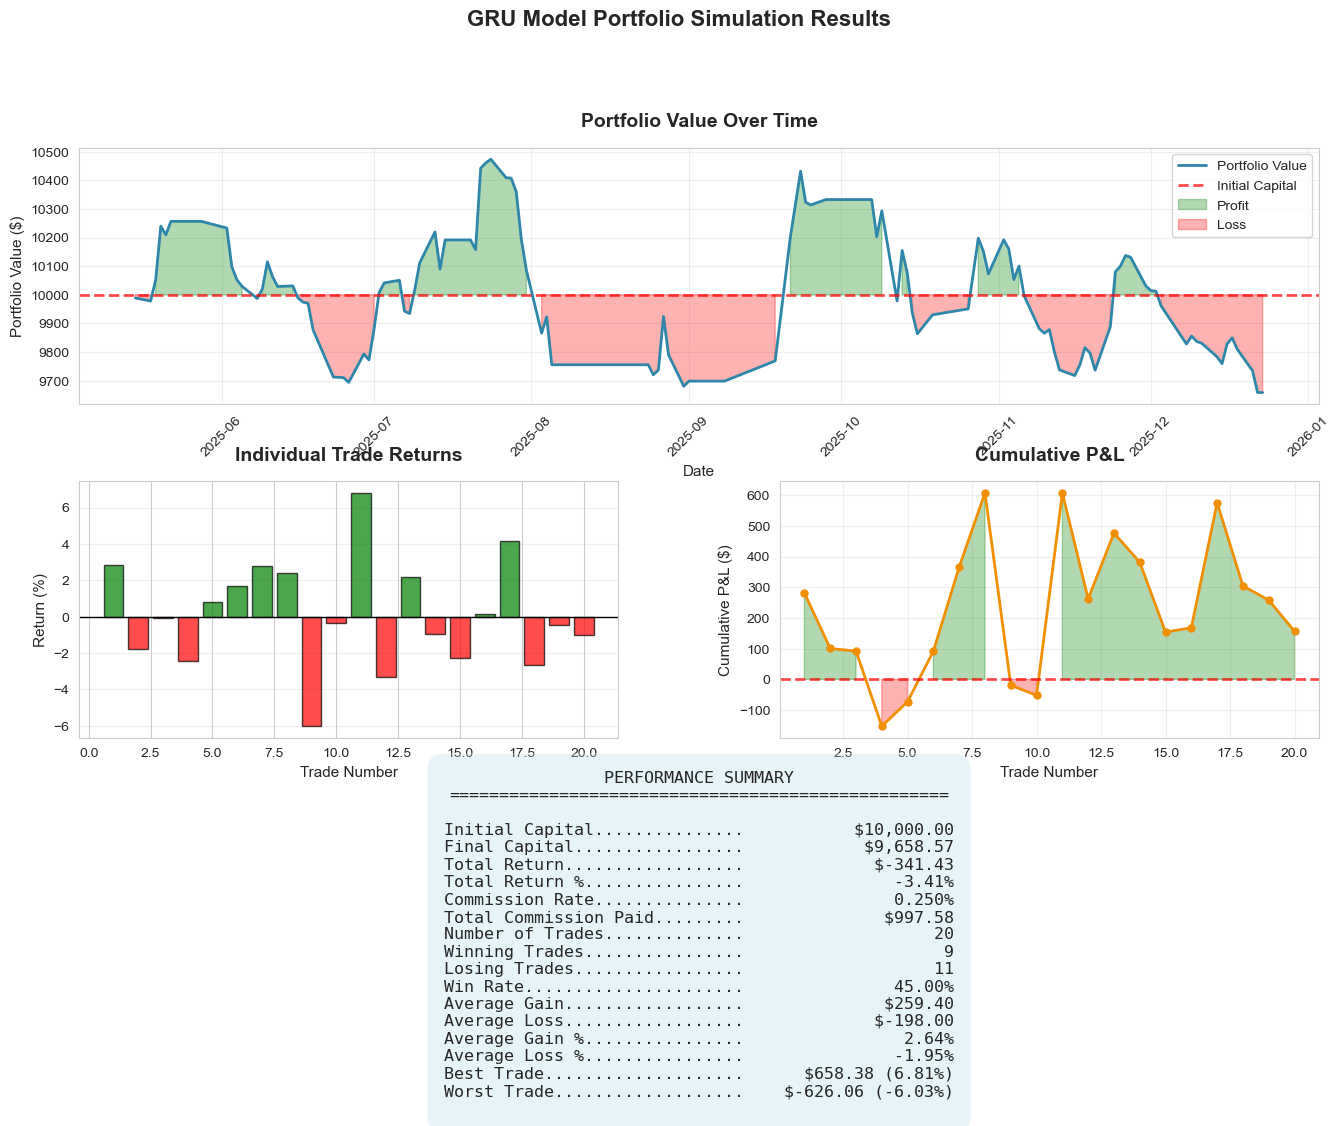

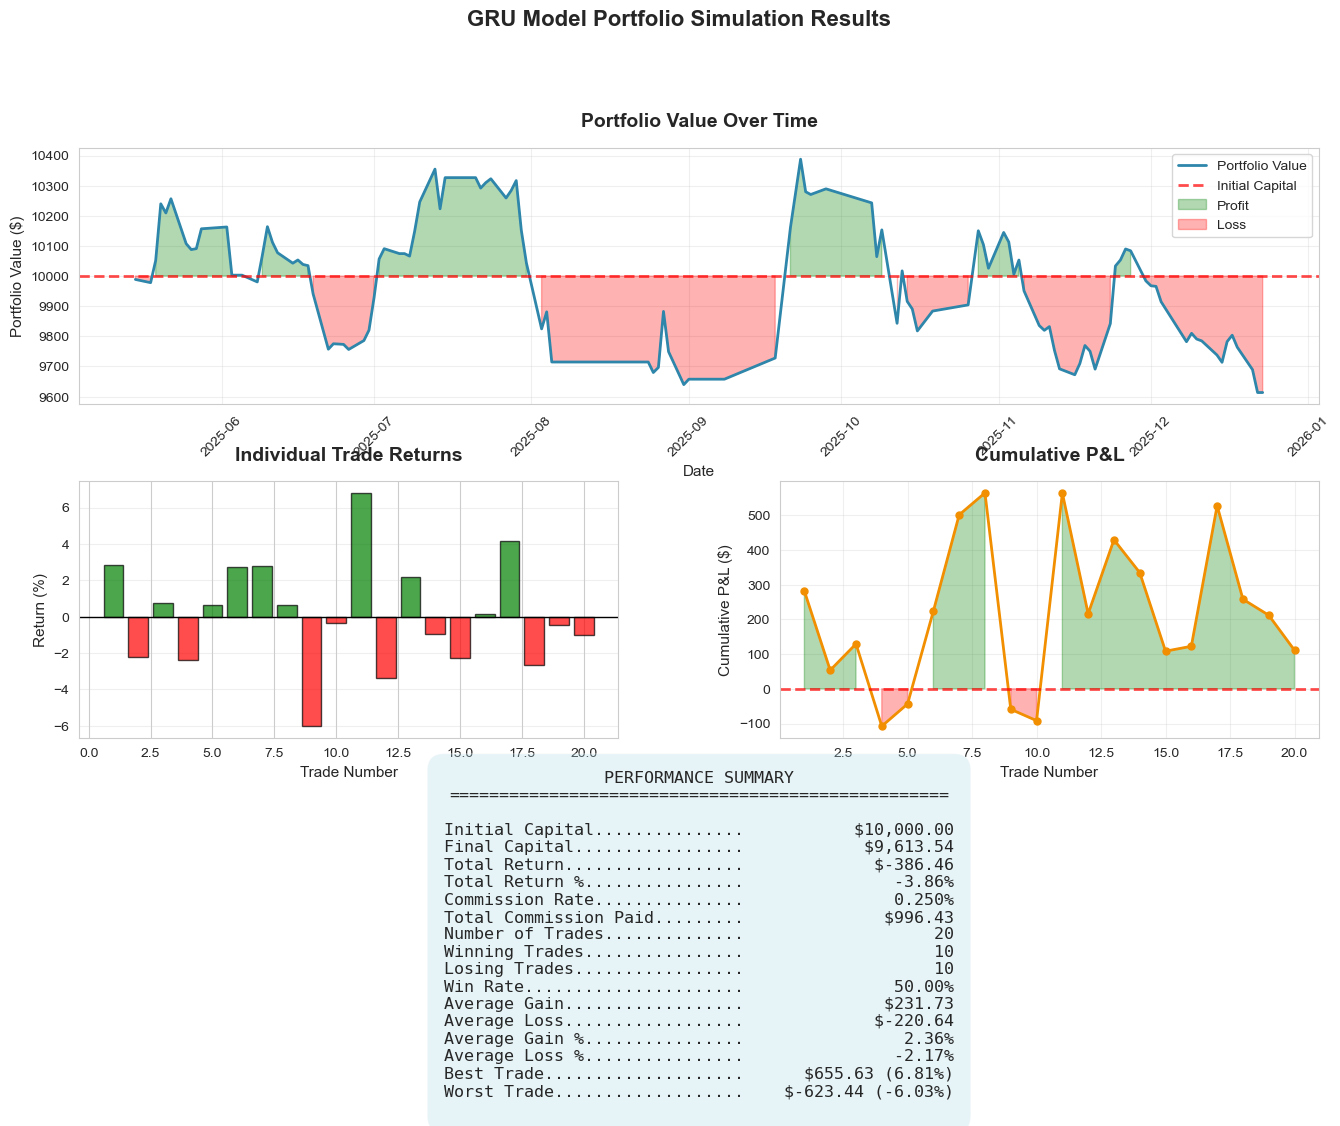

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Models and their CSV files
MODEL_FILES = {
    'sarima': 'sarima_predictions.csv',
    'gbt': 'gbt_predictions15days.csv',
    'lstm': 'model_predictions-lstm-aws.csv',
    'gru': 'model_predictions-gru-aws.csv',
    'adaboost': 'model_predictions_stacked_adaboost.csv',
    'random_forest': 'model_predictions_stacked_rf.csv',
    'stacking_gbt': 'model_predictions_stacked_gbt.csv'
}

STOCK_FILE = 'stock_with_sentiment-aggregated.csv'
INITIAL_CAPITAL = 10000
COMMISSION_RATE = 0.0025  # Adjust as needed

# Create output folders
os.makedirs('simulation_results', exist_ok=True)
os.makedirs('simulation_results/trades', exist_ok=True)
os.makedirs('simulation_results/portfolio', exist_ok=True)
os.makedirs('simulation_results/plots', exist_ok=True)
os.makedirs('simulation_results/metrics', exist_ok=True)


# Reuse your functions: load_and_prepare_data, run_simulation, calculate_metrics, create_visualizations
# (Paste all functions from your current code here)
def load_and_prepare_data(predictions_path, stock_path):
    """
    Load and prepare the data files
    """
    print("Loading data files...")
    
    # Load predictions
    predictions_df = pd.read_csv(predictions_path)
    predictions_df['date'] = pd.to_datetime(predictions_df['date'])
    
    print(f"Loaded {len(predictions_df)} predictions")
    print(f"Date range: {predictions_df['date'].min()} to {predictions_df['date'].max()}")
    print(f"\nPredictions breakdown:")
    print(predictions_df['predicted'].value_counts())
    print(f"  Predicted UP (1): {(predictions_df['predicted']==1).sum()} ({(predictions_df['predicted']==1).sum()/len(predictions_df)*100:.1f}%)")
    print(f"  Predicted DOWN (0): {(predictions_df['predicted']==0).sum()} ({(predictions_df['predicted']==0).sum()/len(predictions_df)*100:.1f}%)")
    
    # Load stock data
    stock_df = pd.read_csv(stock_path)
    
    # Identify columns (assuming standard OHLCV format)
    # Adjust column names if your data has different structure
    date_col = stock_df.columns[6]
    stock_df.rename(columns={date_col: 'date'}, inplace=True)
    stock_df['date'] = pd.to_datetime(stock_df['date'])
    
    print(f"\nLoaded {len(stock_df)} stock data rows")
    print(f"Date range: {stock_df['date'].min()} to {stock_df['date'].max()}")
    print(f"\nStock data columns: {list(stock_df.columns)}")
    
    return predictions_df, stock_df


def run_simulation(predictions_df, stock_df, initial_capital, commission_rate):
    """
    Run the portfolio simulation
    """
    print("\n" + "="*80)
    print("RUNNING PORTFOLIO SIMULATION")
    print("="*80)
    
    # Sort data
    predictions_df = predictions_df.sort_values('date').reset_index(drop=True)
    stock_df = stock_df.sort_values('date').reset_index(drop=True)
    
    # Get available trading dates
    trading_dates = sorted(stock_df['date'].unique())
    date_to_idx = {date: idx for idx, date in enumerate(trading_dates)}
    
    # Identify price columns (looking for 'open' and 'close')
    open_col = [col for col in stock_df.columns if 'o' in col.lower()][0]
    close_col = [col for col in stock_df.columns if 'c' in col.lower()][0]
    
    print(f"\nUsing columns: Open='{open_col}', Close='{close_col}'")
    
    # Create price lookup dictionary
    price_map = {}
    for _, row in stock_df.iterrows():
        price_map[row['date']] = {
            'open': row[open_col],
            'close': row[close_col]
        }
    
    # Initialize simulation variables
    current_capital = initial_capital
    position = None
    trades = []
    portfolio_history = []
    total_commission_paid = 0
    
    # Simulate trading
    for idx, pred_row in predictions_df.iterrows():
        prediction_date = pred_row['date']
        predicted = pred_row['predicted']
        
        # Check if we can get price data for this date
        if prediction_date not in price_map:
            continue
        
        # Close existing position if exit date reached
        if position is not None:
            if prediction_date >= position['exit_date']:
                # Close position
                if position['exit_date'] in price_map:
                    exit_price = price_map[position['exit_date']]['close']
                    gross_proceeds = position['shares'] * exit_price
                    exit_commission = gross_proceeds * commission_rate
                    net_proceeds = gross_proceeds - exit_commission
                    
                    total_commission = position['entry_commission'] + exit_commission
                    pnl = net_proceeds - position['investment']
                    pnl_pct = (pnl / position['investment']) * 100
                    
                    current_capital = net_proceeds
                    total_commission_paid += exit_commission
                    
                    trades.append({
                        'trade_num': len(trades) + 1,
                        'prediction_date': position['prediction_date'],
                        'entry_date': position['entry_date'],
                        'exit_date': position['exit_date'],
                        'entry_price': position['entry_price'],
                        'exit_price': exit_price,
                        'shares': position['shares'],
                        'investment': position['investment'],
                        'gross_proceeds': gross_proceeds,
                        'entry_commission': position['entry_commission'],
                        'exit_commission': exit_commission,
                        'total_commission': total_commission,
                        'net_proceeds': net_proceeds,
                        'pnl': pnl,
                        'pnl_pct': pnl_pct,
                        'capital_after': current_capital
                    })
                    
                    print(f"Trade #{len(trades):3d} | Entry: {position['entry_date'].strftime('%Y-%m-%d')} @ ${position['entry_price']:.2f} | "
                          f"Exit: {position['exit_date'].strftime('%Y-%m-%d')} @ ${exit_price:.2f} | "
                          f"P&L: ${pnl:+.2f} ({pnl_pct:+.2f}%) | Commission: ${total_commission:.2f}")
                
                position = None
        
        # Open new position if predicted UP and no current position
        if position is None and predicted == 1:
            # Find entry date (next trading day)
            if prediction_date in date_to_idx:
                pred_idx = date_to_idx[prediction_date]
                
                # Entry is next trading day
                if pred_idx + 1 < len(trading_dates):
                    entry_date = trading_dates[pred_idx + 1]
                    
                    # Exit is 5 trading days after entry
                    if pred_idx + 5 < len(trading_dates):
                        exit_date = trading_dates[pred_idx + 5]
                        
                        # Get entry price
                        if entry_date in price_map:
                            entry_price = price_map[entry_date]['open']
                            
                            # Calculate shares to buy accounting for entry commission
                            shares = current_capital / (entry_price * (1 + commission_rate))
                            investment = shares * entry_price
                            entry_commission = investment * commission_rate
                            
                            position = {
                                'prediction_date': prediction_date,
                                'entry_date': entry_date,
                                'exit_date': exit_date,
                                'entry_price': entry_price,
                                'shares': shares,
                                'investment': investment,
                                'entry_commission': entry_commission
                            }
                            
                            current_capital = 0  # All capital invested
                            total_commission_paid += entry_commission
        
        # Record portfolio value
        portfolio_value = current_capital
        if position is not None:
            current_price = price_map[prediction_date]['close']
            portfolio_value = position['shares'] * current_price
        
        portfolio_history.append({
            'date': prediction_date,
            'value': portfolio_value,
            'in_position': position is not None
        })
    
    # Close any remaining position
    if position is not None:
        last_date = trading_dates[-1]
        if last_date in price_map:
            exit_price = price_map[last_date]['close']
            gross_proceeds = position['shares'] * exit_price
            exit_commission = gross_proceeds * commission_rate
            net_proceeds = gross_proceeds - exit_commission
            
            total_commission = position['entry_commission'] + exit_commission
            pnl = net_proceeds - position['investment']
            pnl_pct = (pnl / position['investment']) * 100
            
            current_capital = net_proceeds
            total_commission_paid += exit_commission
            
            trades.append({
                'trade_num': len(trades) + 1,
                'prediction_date': position['prediction_date'],
                'entry_date': position['entry_date'],
                'exit_date': last_date,
                'entry_price': position['entry_price'],
                'exit_price': exit_price,
                'shares': position['shares'],
                'investment': position['investment'],
                'gross_proceeds': gross_proceeds,
                'entry_commission': position['entry_commission'],
                'exit_commission': exit_commission,
                'total_commission': total_commission,
                'net_proceeds': net_proceeds,
                'pnl': pnl,
                'pnl_pct': pnl_pct,
                'capital_after': current_capital
            })
    
    return pd.DataFrame(trades), pd.DataFrame(portfolio_history), current_capital, total_commission_paid


def calculate_metrics(trades_df, portfolio_df, initial_capital, final_capital, total_commission_paid, commission_rate):
    """
    Calculate comprehensive performance metrics
    """
    if len(trades_df) == 0:
        print("\nNo trades executed!")
        return None
    
    total_return = final_capital - initial_capital
    total_return_pct = (total_return / initial_capital) * 100
    
    winning_trades = trades_df[trades_df['pnl'] > 0]
    losing_trades = trades_df[trades_df['pnl'] < 0]
    
    metrics = {
        'Initial Capital': f"${initial_capital:,.2f}",
        'Final Capital': f"${final_capital:,.2f}",
        'Total Return': f"${total_return:,.2f}",
        'Total Return %': f"{total_return_pct:.2f}%",
        'Commission Rate': f"{commission_rate*100:.3f}%",
        'Total Commission Paid': f"${total_commission_paid:,.2f}",
        'Number of Trades': len(trades_df),
        'Winning Trades': len(winning_trades),
        'Losing Trades': len(losing_trades),
        'Win Rate': f"{(len(winning_trades)/len(trades_df)*100):.2f}%",
        'Average Gain': f"${winning_trades['pnl'].mean():.2f}" if len(winning_trades) > 0 else "$0.00",
        'Average Loss': f"${losing_trades['pnl'].mean():.2f}" if len(losing_trades) > 0 else "$0.00",
        'Average Gain %': f"{winning_trades['pnl_pct'].mean():.2f}%" if len(winning_trades) > 0 else "0.00%",
        'Average Loss %': f"{losing_trades['pnl_pct'].mean():.2f}%" if len(losing_trades) > 0 else "0.00%",
        'Best Trade': f"${trades_df['pnl'].max():.2f} ({trades_df['pnl_pct'].max():.2f}%)",
        'Worst Trade': f"${trades_df['pnl'].min():.2f} ({trades_df['pnl_pct'].min():.2f}%)",
    }
    
    return metrics


def create_visualizations(trades_df, portfolio_df, metrics, output_file='portfolio_results.png'):
    """
    Create comprehensive visualization of results
    """
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
    
    # Portfolio value over time
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(portfolio_df['date'], portfolio_df['value'], linewidth=2, color='#2E86AB', label='Portfolio Value')
    ax1.axhline(y=float(metrics['Initial Capital'].replace('$', '').replace(',', '')), 
                color='red', linestyle='--', linewidth=2, label='Initial Capital', alpha=0.7)
    ax1.fill_between(portfolio_df['date'], portfolio_df['value'], 
                      float(metrics['Initial Capital'].replace('$', '').replace(',', '')),
                      where=(portfolio_df['value'] >= float(metrics['Initial Capital'].replace('$', '').replace(',', ''))),
                      alpha=0.3, color='green', label='Profit')
    ax1.fill_between(portfolio_df['date'], portfolio_df['value'], 
                      float(metrics['Initial Capital'].replace('$', '').replace(',', '')),
                      where=(portfolio_df['value'] < float(metrics['Initial Capital'].replace('$', '').replace(',', ''))),
                      alpha=0.3, color='red', label='Loss')
    ax1.set_title('Portfolio Value Over Time', fontsize=14, fontweight='bold', pad=15)
    ax1.set_xlabel('Date', fontsize=11)
    ax1.set_ylabel('Portfolio Value ($)', fontsize=11)
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    # Trade P&L distribution
    ax2 = fig.add_subplot(gs[1, 0])
    colors = ['green' if x > 0 else 'red' for x in trades_df['pnl_pct']]
    ax2.bar(trades_df['trade_num'], trades_df['pnl_pct'], color=colors, alpha=0.7, edgecolor='black')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax2.set_title('Individual Trade Returns', fontsize=14, fontweight='bold', pad=15)
    ax2.set_xlabel('Trade Number', fontsize=11)
    ax2.set_ylabel('Return (%)', fontsize=11)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Cumulative returns
    ax3 = fig.add_subplot(gs[1, 1])
    trades_df['cumulative_pnl'] = trades_df['pnl'].cumsum()
    ax3.plot(trades_df['trade_num'], trades_df['cumulative_pnl'], 
             linewidth=2, color='#F18F01', marker='o', markersize=5)
    ax3.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax3.fill_between(trades_df['trade_num'], trades_df['cumulative_pnl'], 0,
                      where=(trades_df['cumulative_pnl'] >= 0),
                      alpha=0.3, color='green')
    ax3.fill_between(trades_df['trade_num'], trades_df['cumulative_pnl'], 0,
                      where=(trades_df['cumulative_pnl'] < 0),
                      alpha=0.3, color='red')
    ax3.set_title('Cumulative P&L', fontsize=14, fontweight='bold', pad=15)
    ax3.set_xlabel('Trade Number', fontsize=11)
    ax3.set_ylabel('Cumulative P&L ($)', fontsize=11)
    ax3.grid(True, alpha=0.3)
    
    # Performance metrics table
    ax4 = fig.add_subplot(gs[2, :])
    ax4.axis('off')
    
    metrics_text = "PERFORMANCE SUMMARY\n" + "="*50 + "\n\n"
    for key, value in metrics.items():
        metrics_text += f"{key:.<30} {value:>20}\n"
    
    ax4.text(0.5, 0.5, metrics_text, fontsize=12, family='monospace',
            verticalalignment='center', horizontalalignment='center',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3, pad=1))
    
    plt.suptitle('GRU Model Portfolio Simulation Results', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"\nVisualization saved to: {output_file}")
    
    return fig




















# ---- BATCH SIMULATION ----
for model_name, pred_file in MODEL_FILES.items():
    print("\n" + "="*80)
    print(f"Running simulation for model: {model_name.upper()}")
    print("="*80)

    try:
        # Load data
        predictions_df, stock_df = load_and_prepare_data(pred_file, STOCK_FILE)

        # Run simulation
        trades_df, portfolio_df, final_capital, total_commission_paid = run_simulation(
            predictions_df, stock_df, INITIAL_CAPITAL, COMMISSION_RATE
        )

        # Calculate metrics
        metrics = calculate_metrics(trades_df, portfolio_df, INITIAL_CAPITAL, final_capital,
                                    total_commission_paid, COMMISSION_RATE)

        # Print summary
        print("\nPerformance Metrics:")
        for key, value in metrics.items():
            print(f"{key:.<40} {value:>20}")

        # Save results
        trades_df.to_csv(f'simulation_results/trades/trades_{model_name}.csv', index=False)
        portfolio_df.to_csv(f'simulation_results/portfolio/portfolio_{model_name}.csv', index=False)

        # Save metrics summary
        with open(f'simulation_results/metrics/metrics_{model_name}.txt', 'w') as f:
            for key, value in metrics.items():
                f.write(f"{key:.<40} {value:>20}\n")

        # Save plots
        create_visualizations(trades_df, portfolio_df, metrics,
                              output_file=f'simulation_results/plots/portfolio_{model_name}.png')

        print(f"\n✓ Simulation completed and saved for {model_name.upper()}\n")

    except Exception as e:
        print(f"❌ Error running simulation for {model_name.upper()}: {e}")
